In [28]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from scipy.stats import norm

torch.manual_seed(42)

## Starting with a simple normal distribution case

Data Mean: 5.10


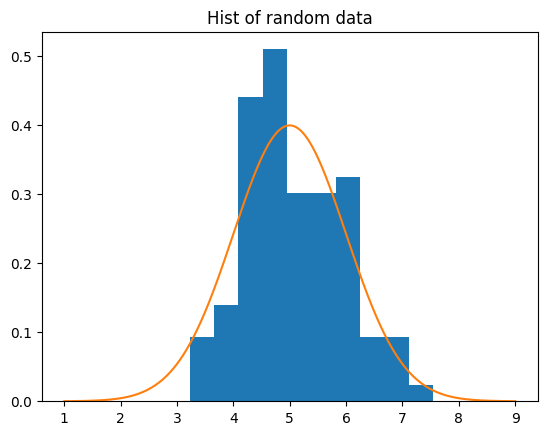

In [27]:
true_mean = 5.0
n_samples = 100

# Likelihood: p(x|z) = N(z, 1)
data = torch.randn(n_samples) + true_mean

print(f"Data Mean: {data.mean().item():.2f}")

x = np.linspace(true_mean - 4 * 1, true_mean + 4 * 1, 1000)
y = norm.pdf(x, loc=true_mean, scale=1)

plt.hist(data, density=True)
plt.title("Hist of random data")
plt.plot(x,y)
plt.show()

In [26]:
torch.distributions.Normal(0, 10).sample((1,10))

tensor([[ -5.6691,  -0.2670, -15.4597, -21.7990,   2.0738, -19.8436,  -1.8166,
           4.2797,   2.5455,   0.6618]])

The Prior $P(z)$: Our belief about the mean before seeing data. We use a wide Gaussian $\mathcal{N}(0, 10)$.

The Variational Posterior $Q_\phi(z)$: The distribution we are trying to learn to approximate the true posterior. We use a Gaussian $\mathcal{N}(\mu_{q}, \sigma_{q})$.

We define mean_q and log_std_q as learnable PyTorch parameters. We use log standard deviation to ensure the scale remains positive during optimization.

In [33]:
# 2. Parameters to optimize (Variational Parameters)
# We want to learn mean_q and std_q that make Q(z) close to P(z|x)
mean_q = torch.tensor([0.0], requires_grad=True)
log_std_q = torch.tensor([0.0], requires_grad=True) # Work in log space for stability

def get_q_dist(mean, log_std):
    return dist.Normal(mean, torch.exp(log_std))

def get_prior_dist():
    return dist.Normal(0.0, 10.0)

This is the core training loop. We maximize the Evidence Lower Bound (ELBO), which is equivalent to minimizing the Kullback-Leibler (KL) divergence between our estimate $Q(z)$ and the true posterior $P(z|x)$.  
In each step, we:  
- Sample $z$ from our current $Q(z)$ using the reparameterization trick.
- Calculate Likelihood of the data given that sample $z$.
- Calculate Probabilities for the prior and the variational distribution.
- Compute Loss as the negative ELBO: $- (\log P(x|z) + \log P(z) - \log Q(z))$.

Note:
Reparameterization:

$$
z = \mu + \sigma \epsilon, \quad \epsilon \sim \mathcal{N}(0,1)
$$

Loss:
$$
\mathcal{L} = (z - 5)^2
$$

Gradients:
$$
\frac{\partial \mathcal{L}}{\partial z} = 2(z - 5)
$$
$$
\frac{\partial \mathcal{L}}{\partial \mu} = 2(z - 5)
$$
$$
\frac{\partial \mathcal{L}}{\partial \sigma} = 2(z - 5)\epsilon
$$

Example ($\mu=2,\ \sigma=3,\ \epsilon=0.4$):

$$
z = 3.2, \quad
\frac{\partial \mathcal{L}}{\partial \mu} = -3.6, \quad
\frac{\partial \mathcal{L}}{\partial \sigma} = -1.44
$$

$\epsilon$ is a standard normal draw.


Note: 
Log-probability of a Normal:

$$
\log p(z \mid \mu, \sigma)
=
-\frac{1}{2}\left(
\frac{(z-\mu)^2}{\sigma^2}
+ 2\log \sigma
+ \log 2\pi
\right)
$$



#### 1. Sample from the variational distribution

$$
z \sim q(z \mid \mu_q, \sigma_q)
\quad\text{via}\quad
z = \mu_q + \sigma_q \epsilon
$$

This keeps gradients flowing to $\mu_q, \sigma_q$.

---

#### 2. Log probabilities

**Prior:**
$$
\log p(z)
$$

Pushes $z$ toward the prior (e.g. $\mathcal{N}(0,1)$).

**Likelihood:**
$$
\log p(x \mid z)
$$

Measures how well $z$ explains the data.

**Variational density:**
$$
\log q(z \mid x)
$$

Penalizes putting too much mass where we sampled.

---

#### 3. ELBO

$$
\text{ELBO}
=
\log p(x \mid z)
+
\log p(z)
-
\log q(z \mid x)
$$

Interpretation:

$$
\text{ELBO}
=
\underbrace{\text{fit to data}}_{\text{likelihood}}
-
\underbrace{\text{KL}(q \| p)}_{\text{regularization}}
$$

---

#### 4. Loss

$$
\text{loss} = -\text{ELBO}
$$

We minimize this to:

- Increase likelihood (better reconstruction)
- Keep $q(z \mid x)$ close to the prior
- Learn $\mu_q, \sigma_q$ via backprop through $z$


In [ ]:
# Re-initialize parameters
mean_q = torch.tensor([0.0], requires_grad=True)
log_std_q = torch.tensor([0.0], requires_grad=True)

# Hyperparameters
lr = 0.01  # Learning Rate
n_steps = 100
loss_history = []

for step in range(n_steps):
    # --- Forward Pass ---
    
    # 1. Sample (Reparameterization Trick)
    q_dist = get_q_dist(mean_q, log_std_q)
    z_sample = q_dist.rsample()

    # 2. Calculate Log Probs
    prior_log_prob = get_prior_dist().log_prob(z_sample)
    
    likelihood_dist = dist.Normal(z_sample, 1.0)
    likelihood_log_prob = likelihood_dist.log_prob(data).sum()

    q_log_prob = q_dist.log_prob(z_sample)

    # 3. Loss (Negative ELBO)
    elbo = likelihood_log_prob + prior_log_prob - q_log_prob
    loss = -elbo
    
    loss_history.append(loss.item())

    # --- Backward Pass & Manual Update ---

    # 4. Compute Gradients
    loss.backward()

    # 5. Manual Gradient Descent Step
    with torch.no_grad():
        # Update Mean: theta = theta - lr * grad
        mean_q -= lr * mean_q.grad
        
        # Update Log Std
        log_std_q -= lr * log_std_q.grad
        
        # 6. CRITICAL: Zero out gradients for the next step
        mean_q.grad.zero_()
        log_std_q.grad.zero_()

    if step % 500 == 0:
        curr_sigma = torch.exp(log_std_q).item()
        print(f"Step {step} | Loss: {loss.item():.2f} | Est Mean: {mean_q.item():.2f} | Est Std: {curr_sigma:.2f}")

print(f"Final Estimated Mean: {mean_q.item():.4f}")
print(f"Final Estimated Std: {torch.exp(log_std_q).item():.4f}")

Step 0 | Loss: 1546.94 | Est Mean: 5.32 | Est Std: 0.33
Final Estimated Mean: 5.2074
Final Estimated Std: 0.1068


In [46]:
q_dist.rsample()

tensor([5.1178], grad_fn=<AddBackward0>)

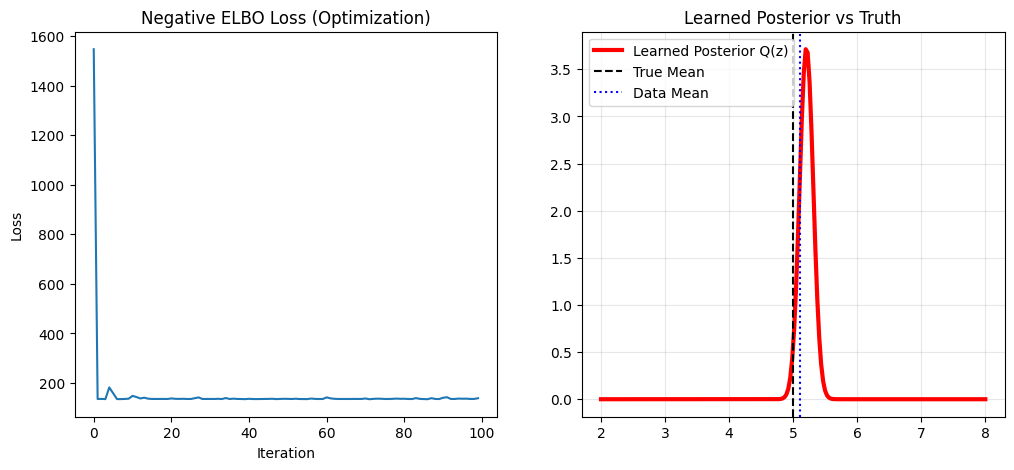

In [40]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Negative ELBO Loss (Optimization)")
plt.xlabel("Iteration")
plt.ylabel("Loss")

# Plot Posterior Density
plt.subplot(1, 2, 2)
z_range = torch.linspace(2, 8, 200)

# Get the final learned distribution
final_q = get_q_dist(mean_q, log_std_q)
q_density = torch.exp(final_q.log_prob(z_range)).detach()

plt.plot(z_range.numpy(), q_density.numpy(), label='Learned Posterior Q(z)', color='red', lw=3)
plt.axvline(true_mean, color='black', linestyle='--', label='True Mean')
plt.axvline(data.mean(), color='blue', linestyle=':', label='Data Mean')

plt.title("Learned Posterior vs Truth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()